In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import adspfilter
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
def set_dark_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "#000000",
        "axes.facecolor":   "#000000",
        "axes.edgecolor":   "#FFFFFF",
        "axes.labelcolor":  "#FFFFFF",
        "text.color":       "#FFFFFF",
        "xtick.color":      "#FFFFFF",
        "ytick.color":      "#FFFFFF",
        "grid.color":       "#444444",
        "legend.facecolor": "#000000",
        "legend.edgecolor": "#FFFFFF",
        "savefig.facecolor":"#000000",
        "savefig.edgecolor":"#000000",
    })
set_dark_style()

In [2]:
h_true = np.array([0.1, 0.3, 0.0, -0.2, -0.4, -0.7, -0.4, -0.2], dtype=np.float64)
M = len(h_true)

# ==============================================================
# AR(1) generator with target eigenvalue spread
# ==============================================================
def ar1Input(a, N, sigma_v2=1.0):
  v = np.sqrt(sigma_v2) * np.random.randn(N)
  x = np.zeros(N)
  for n in range(1, N):
    x[n] = a * x[n-1] + v[n]
  x /= np.std(x)
  return x


def runSysID(
    model,
    spread=20,
    N=500,
    sigma_n2=1e-4,
    n_runs=200,
    burnin=2000,
):
  """
  Monte-Carlo averaged MSE learning curve
  """
  a = adspfilter.ar1poleSpreadSearch(spread, M)

  # determine output length dynamically
  x_test = ar1Input(a, N + M)
  d_test = np.convolve(x_test, h_true)[:N]
  model.w = np.zeros(M)
  _, e_test, _ = model(x_test[:N], d_test, train=False)
  out_len = len(e_test)

  mse_runs = np.zeros((n_runs, out_len))

  for r in range(n_runs):
    x = ar1Input(a, N + M)        
    noise = np.sqrt(sigma_n2) * np.random.randn(N)
    d = np.convolve(x, h_true)[:N] + noise
    model.w = np.zeros(M)                      # reset weights
    y, e, _ = model(x[:N], d, train=True)
    mse_runs[r] = np.abs(e)**2

  mse_avg = np.mean(mse_runs, axis=0)
  burn = min(burnin, out_len // 2)
  misadj = (np.mean(mse_avg[burn:]) - sigma_n2) / sigma_n2

  return mse_avg, misadj

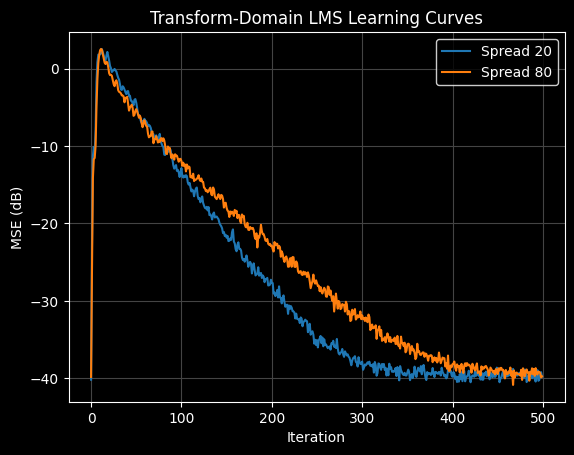

Misadjustment Spread 20: 0.412032834507894
Misadjustment Spread 80: 2.6681728650653205


In [3]:
# Example 4.8 — Transform-Domain LMS
# Transform-Domain LMS (DCT)
td_model = adspfilter.TransformDomain(
    mu=0.01,
    filter_order=M-1,
    matrix="dct",
    alpha=0.05,
    gamma=1e-6
)

mse20, M20 = runSysID(td_model, spread=20)
mse80, M80 = runSysID(td_model, spread=80)

plt.figure()
plt.plot(10*np.log10(mse20), label="Spread 20")
plt.plot(10*np.log10(mse80), label="Spread 80")
plt.title("Transform-Domain LMS Learning Curves")
plt.xlabel("Iteration")
plt.ylabel("MSE (dB)")
plt.legend()
plt.grid()
plt.show()

print("Misadjustment Spread 20:", M20)
print("Misadjustment Spread 80:", M80)

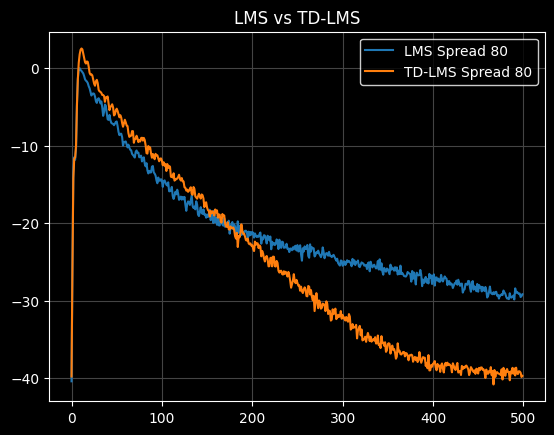

In [4]:
lms_model = adspfilter.LMS(mu=0.01, filter_order=M-1)

mse_lms_80, M_lms_80 = runSysID(lms_model, spread=80)

plt.figure()
plt.plot(10*np.log10(mse_lms_80), label="LMS Spread 80")
plt.plot(10*np.log10(mse80), label="TD-LMS Spread 80")
plt.legend()
plt.title("LMS vs TD-LMS")
plt.grid()
plt.show()

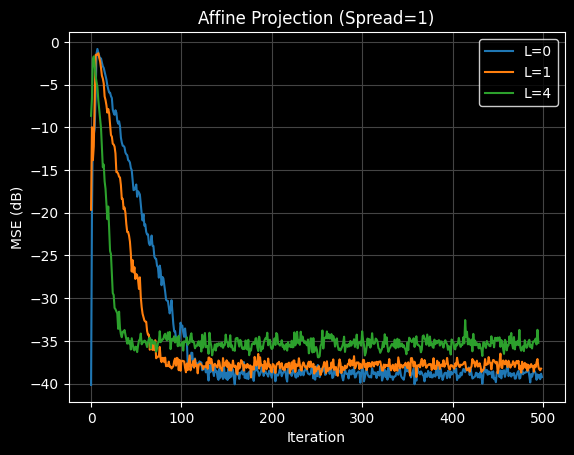

In [5]:
for L in [0, 1, 4]:
  apa = adspfilter.AffineProjection(mu=0.4, filter_order=M-1, P=L)
  mse, M_val = runSysID(apa, spread=1)

  plt.plot(10*np.log10(mse), label=f"L={L}")

plt.title("Affine Projection (Spread=1)")
plt.xlabel("Iteration")
plt.ylabel("MSE (dB)")
plt.legend()
plt.grid()
plt.show()